Stroke Prediction Tutorial

In [212]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

In [213]:
# Load the Dataset 
stroke_data=pd.read_csv(r'C:\Users\ali59\OneDrive\Desktop\Data Science AI\Lecture 15\healthcare-dataset-stroke-data.csv')
display(stroke_data)

print('----Data Info----')
stroke_data.info()

print('--Describe Data Statistically--')
stroke_data.describe().T

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


----Data Info----
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB
--Describe Data Statistically--


,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


Insights from the above info () and describe() function :
1. Data Types : We have 5 numerical columns - Age,hypertension ,heart_disease ,avg_glucose_level and bmi
and we have 5 categorical columns - gender,ever_married,work_type,residence_type and smoking status.
2.We must encode the categorical columns into numeric format before training as Machine Learning models only understand numbers.
3.BMI column has some missing values ,it has only  4,909 non-null entries out of 5,110 total rows.
 We have 201 missing values in bmi. We cannot feed missing data (NaN) to our model. This tells us we must either drop these rows or fill them (impute) in our preprocessing step.
 


Exploratory Data Analysis.

In [214]:
# We need to separate out our numeric and categorical columns 
target_col='stroke'
id_col='id'
#get all categorical columns 
cat_col=stroke_data.select_dtypes(include=['str']).columns.tolist()
num_col=stroke_data.select_dtypes(include=['int64','float64']).columns.tolist()
#remove target n ID column 
num_col.remove('stroke')
num_col.remove('id')


In [215]:
#removing hyper tension and heart disease column from numeric col and adding it to the categorical col
numeric_col=[]
for i in num_col:
    if stroke_data[i].nunique()<3:
        cat_col.append(i)
    else:
        numeric_col.append(i)
print("Automatically identified Categorical Columns:\n", cat_col)
print("\nAutomatically identified Numerical Columns:\n", numeric_col)        


Automatically identified Categorical Columns:
 ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'hypertension', 'heart_disease']

Automatically identified Numerical Columns:
 ['age', 'avg_glucose_level', 'bmi']


Univariant Analysis :
Univariate analysis looks at a single variable at a time. This tells us the distribution of the data, the presence of outliers, and the balance of categories.

For Numerical columns, we use Histograms and Boxplots. For Categorical columns, we use Countplots.

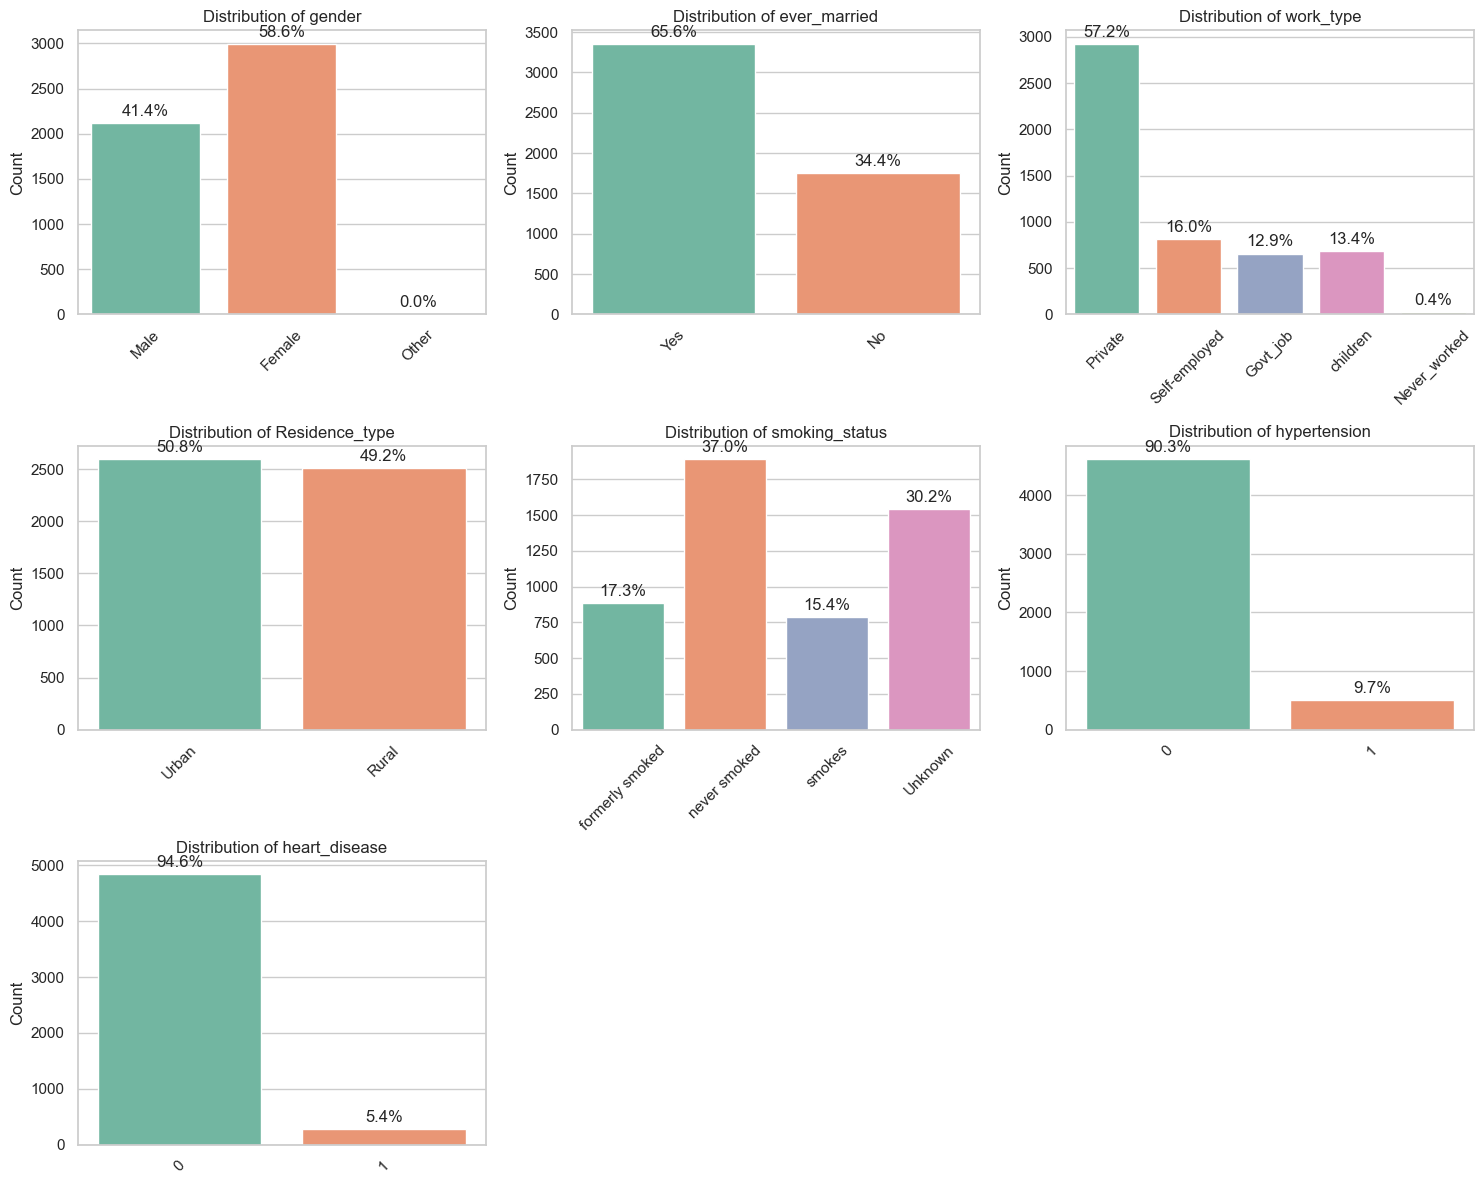

In [216]:
# Categorical Features - Building countplots
plt.figure(figsize=(15,12))  # width - 15, height-12 for the figure
#Loop through each categorical data and build the countplot 
for i,col in enumerate(cat_col):
    ax=plt.subplot(3,3,i+1)                  # here we are creating 3x3 grid subplot 
    #plot a bar chart 
    sns.countplot(data=stroke_data,x=col,palette='Set2')
    #Title and labels
    plt.title(f'Distribution of {col}',fontsize=12)
    plt.xlabel('')
    plt.ylabel('Count')
    # Rotate x-axis labels to prevent overlap if names are long
    plt.xticks(rotation=45)
    #Add percentage on top of each bar 
    total=len(stroke_data)   # gives total number of rows in the dataset 
    for c in ax.containers:
        percentage=[f'{100*v.get_height()/total:.1f}%' for v in c]   #  percentage: (height of bar / total rows) * 100
    
        ax.bar_label(c,labels=percentage,label_type='edge',padding=3)
    plt.tight_layout()    



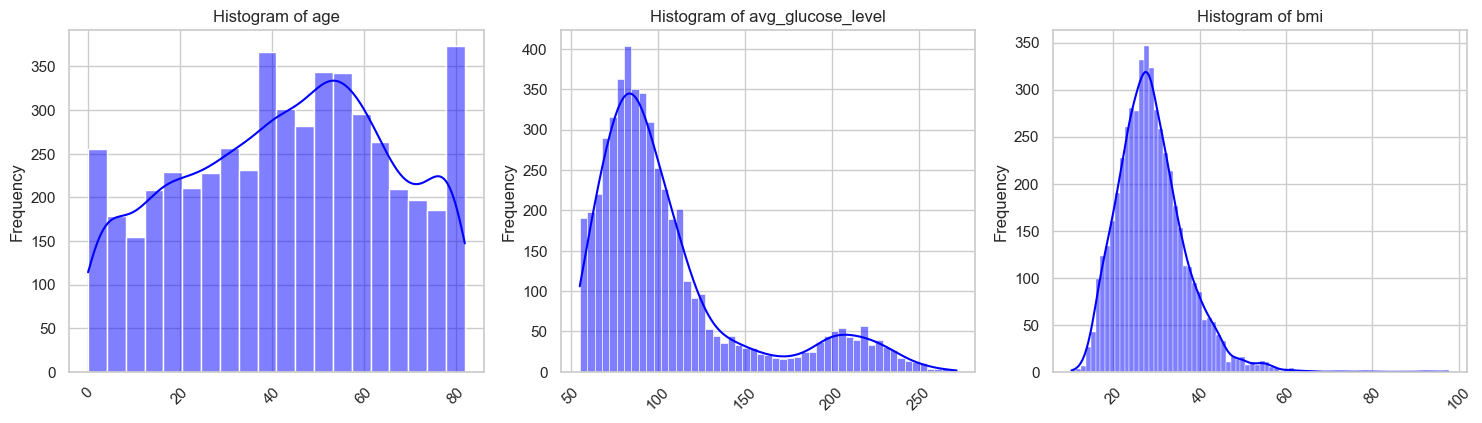

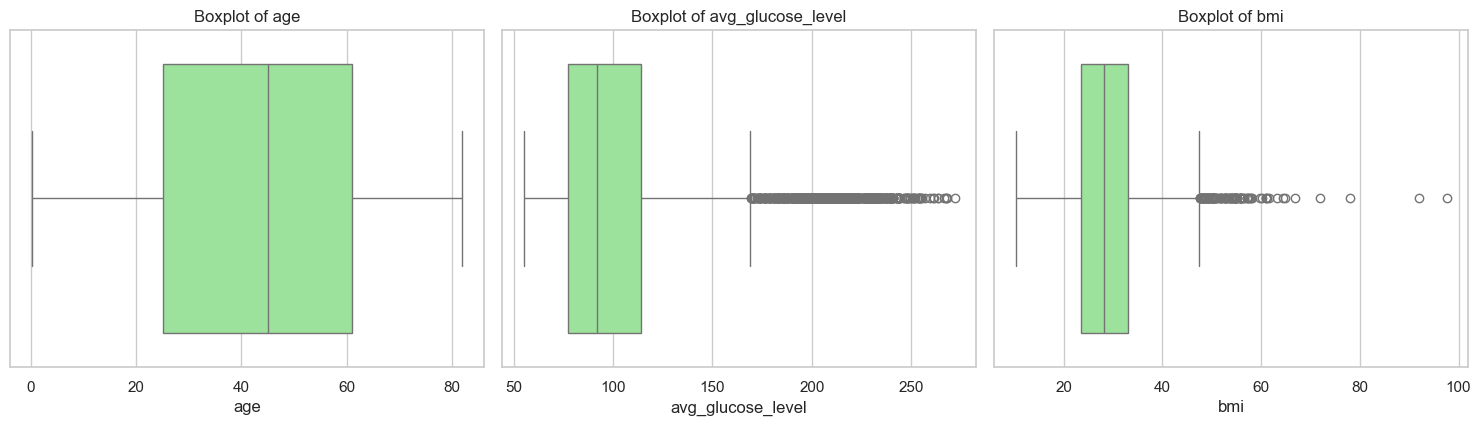

In [217]:
#Numerical Features - Build Histplots 
plt.figure(figsize=(15,12))

#Loop through each numerical data and build the countplot 
for i,col in enumerate(numeric_col):
    ax=plt.subplot(3,3,i+1)                  # here we are creating 3x3 grid subplot 
    #plot a bar chart 
    sns.histplot(data=stroke_data,x=col,kde=True,color='blue')
    #Title and labels
    plt.title(f'Histogram of {col}',fontsize=12)
    plt.xlabel('')
    plt.ylabel('Frequency')
    # Rotate x-axis labels to prevent overlap if names are long
    plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()

#Numerical Features - Build boxplot to detect outliers
plt.figure(figsize=(15,12))
#Loop through each numerical data and build the countplot 
for i,col in enumerate(numeric_col):
    ax=plt.subplot(3,3,i+1)                  # here we are creating 3x3 grid subplot 
    #plot a bar chart 
    sns.boxplot(data=stroke_data,x=col,color='lightgreen')
    #Title and labels
    plt.title(f'Boxplot of {col}',fontsize=12)
    plt.xlabel(col)
    
    
    
plt.tight_layout()
plt.show()

The Target Variable & Class Imbalance

stroke
0    4861
1     249
Name: count, dtype: int64


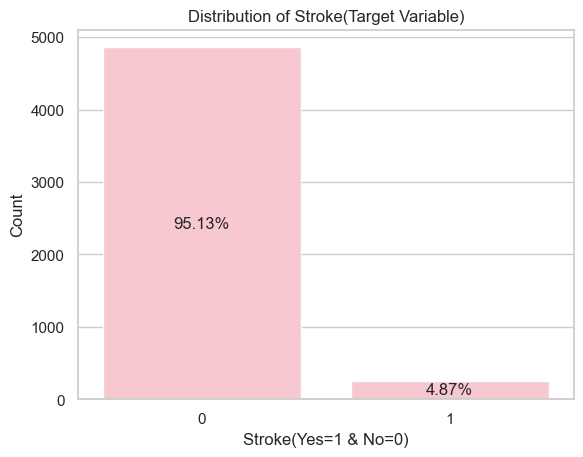

In [218]:
#Count of the Target feature
stroke_count=stroke_data[target_col].value_counts()
print(stroke_count)
# Countplot to visualize the imbalance class 
c_plot=sns.countplot(data=stroke_data,x=target_col,color='pink')
plt.title('Distribution of Stroke(Target Variable)')
plt.xlabel('Stroke(Yes=1 & No=0)')
plt.ylabel('Count')

# Add percentage above the bars

for p in c_plot.containers:
    perc= [f'{100*v.get_height()/total:.2f}%' for v in p]
    c_plot.bar_label(p,labels=perc,label_type='center')
    plt.show()


 We gave detected highly imbalance class that we need to tackle or else our model becomes highly biased towards 0(No stroke ) class. 

Bivariant Analysis : Now we look at 2 variables at a time to check how are the features related to the target columns.

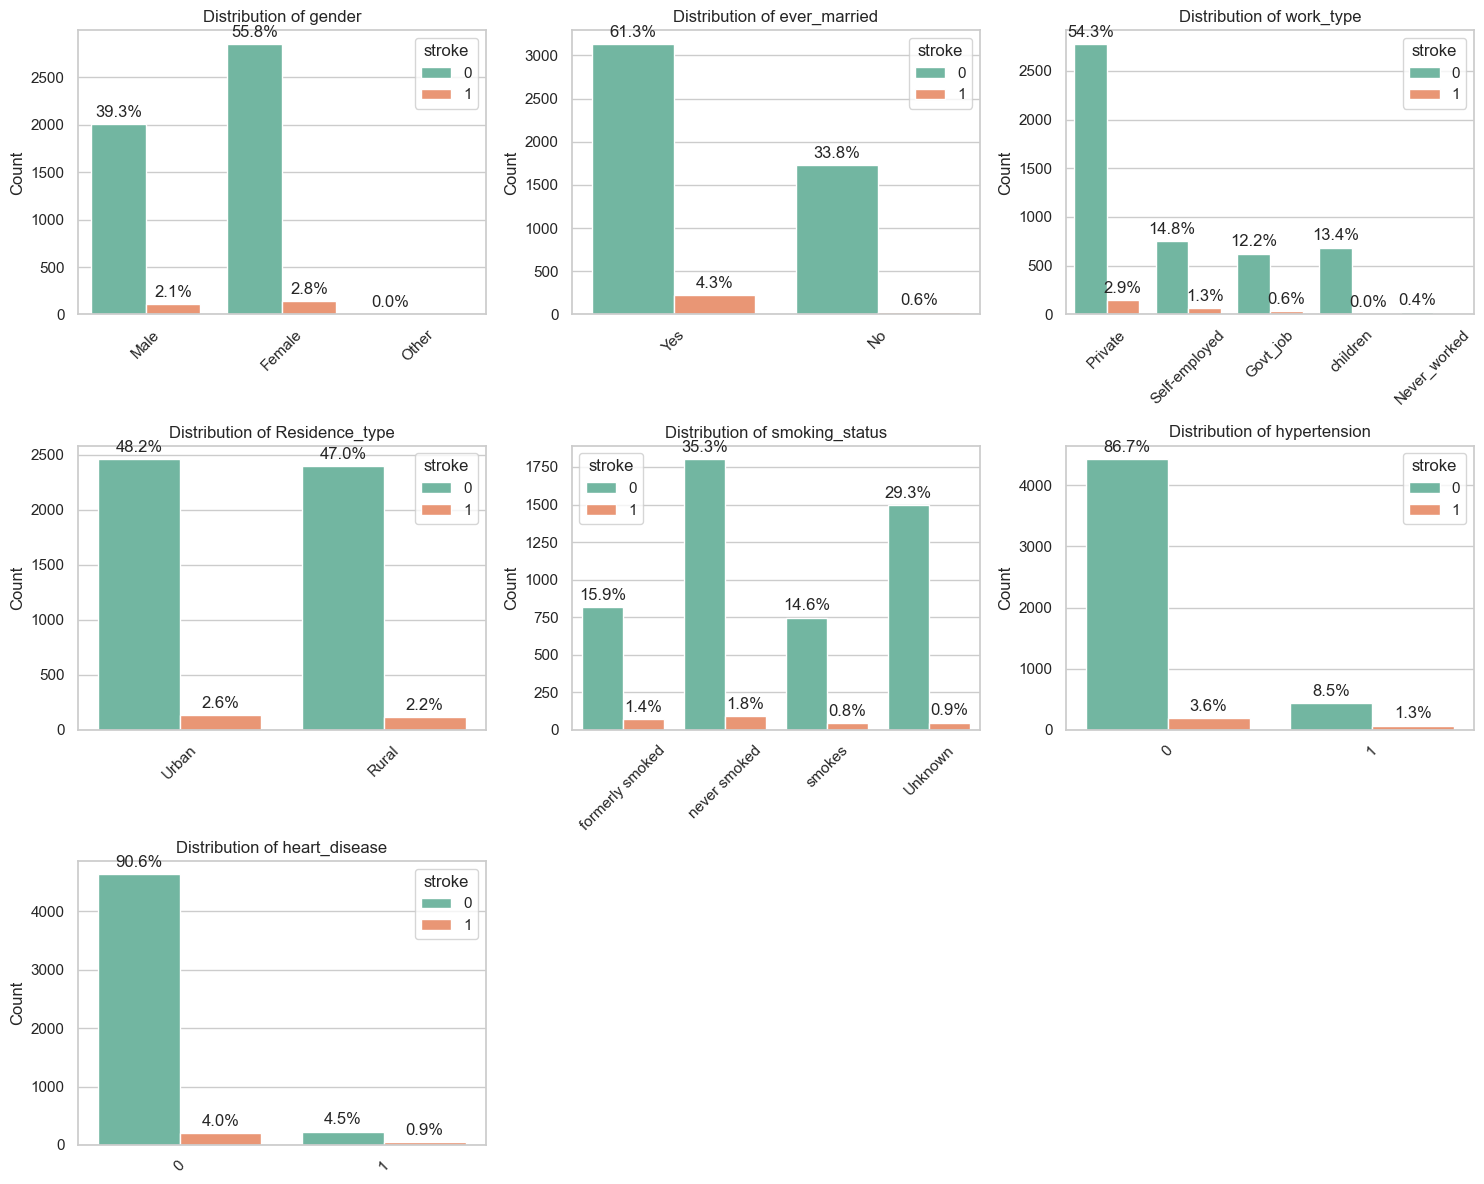

In [219]:
# Categorical Features Vs Target - Building countplots
plt.figure(figsize=(15,12))  # width - 15, height-12 for the figure
#Loop through each categorical data and build the countplot 
for i,col in enumerate(cat_col):
    ax=plt.subplot(3,3,i+1)                  # here we are creating 3x3 grid subplot 
    #plot a bar chart 
    sns.countplot(data=stroke_data,x=col,hue=target_col,palette='Set2')
    #Title and labels
    plt.title(f'Distribution of {col}',fontsize=12)
    plt.xlabel('')
    plt.ylabel('Count')
    # Rotate x-axis labels to prevent overlap if names are long
    plt.xticks(rotation=45)
    #Add percentage on top of each bar 
    total=len(stroke_data)   # gives total number of rows in the dataset 
    for c in ax.containers:
        percentage=[f'{100*v.get_height()/total:.1f}%' for v in c]   #  percentage: (height of bar / total rows) * 100
    
        ax.bar_label(c,labels=percentage,label_type='edge',padding=3)
    plt.tight_layout()    


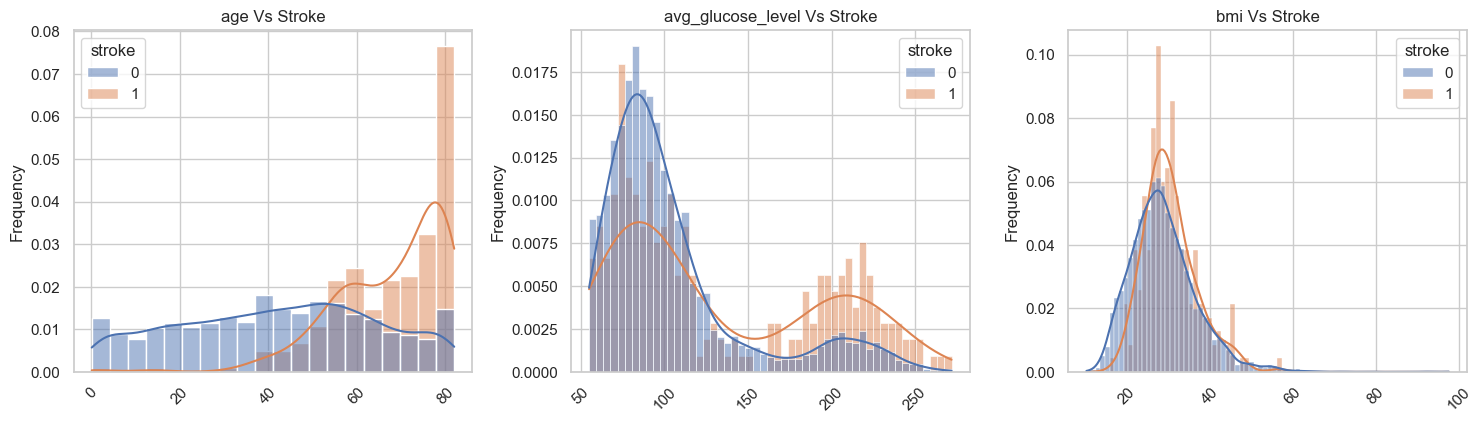

In [220]:
#Numerical Features Vs Target- Build Histplots 
plt.figure(figsize=(15,12))

#Loop through each numerical data and build the countplot 
for i,col in enumerate(numeric_col):
    ax=plt.subplot(3,3,i+1)                  # here we are creating 3x3 grid subplot 
    #plot a bar chart 
    sns.histplot(data=stroke_data,x=col,hue=target_col,kde=True,stat='density',common_norm=False,color='blue')
    #Title and labels
    plt.title(f'{col} Vs Stroke',fontsize=12)
    plt.xlabel('')
    plt.ylabel('Frequency')
    # Rotate x-axis labels to prevent overlap if names are long
    plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()

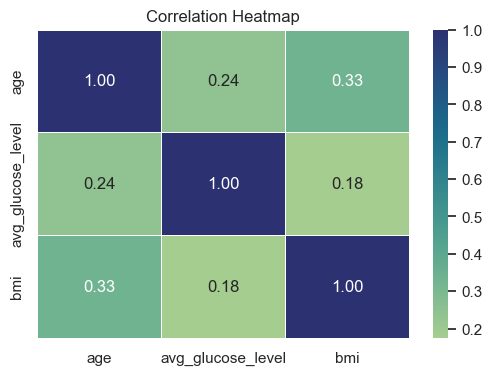

In [221]:
# Correlation Matrix for Numerical Features
plt.figure(figsize=(6, 4))
correlation_matrix = stroke_data[numeric_col].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Correlation heatmap signifies that we dont have multicolinearity issue in our dataset. Highest correlation is 0.33 and none of the features have a colinearity above that.

Data Preprocessing and Feature Engineeering 

In [222]:
# Import required libraries 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,FunctionTransformer
from sklearn.model_selection import train_test_split

In [223]:
# Separate the Target and Feature variables , and drop ID column as it is not required and doesnt add any meaning to the dataset
X=stroke_data.drop(['stroke','id'],axis=1)   
Y=stroke_data['stroke']
# Split the data into train and test sets 
x_train ,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=42)

In [224]:
# Define our custom feature engineering functions
def categorize_features(df_in):
    df = df_in.copy()
    
    # 1. High Glucose Flag
    df['is_high_glucose'] = (df['avg_glucose_level'] > 150).astype(int)
    
    # 2. BMI Categories
    bins = [0, 18.5, 25, 30, 100]
    labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
    # Use fillna to handle missing BMI values temporarily before the imputer catches them
    df['bmi_category'] = pd.cut(df['bmi'].fillna(df['bmi'].median()), bins=bins, labels=labels)
    
    # 3. Age Categories
    age_bins = [0, 18, 65, 150]
    age_labels = ['Child', 'Adult', 'Senior']
    df['age_category'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)
    
    # 4. Health Risk Score (Sum of risk factors)
    df['health_risk_score'] = (
        (df['age_category'] == 'Senior').astype(int) +
        df['hypertension'] +
        df['heart_disease'] +
        (df['bmi_category'].isin(['Overweight', 'Obese'])).astype(int) +
        (df['smoking_status'] == 'smokes').astype(int)
    )
    
    return df

#Create a transformer from our custom function
custom_fe = FunctionTransformer(categorize_features)

     

In [225]:
# Define which columns get which mathematical treatments
numerical_col = ['age', 'avg_glucose_level', 'bmi', 'health_risk_score']
# Notice we added our newly engineered categorical features to the categorical list!
categorical_col = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'bmi_category', 'age_category']
#Numeric pipeline 
num_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy='median'))
])
#categorical pipeline 
cat_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy='most_frequent')),
    ("encoder",OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
#Combine them into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_col),
    ('cat', cat_pipeline, categorical_col)
], remainder='passthrough') # pass through 'is_high_glucose', 'hypertension', etc
# Main Pipeline 
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
full_pipeline=Pipeline([
   ( 'feature engineering',custom_fe),
   ('preprocessor',preprocessor),
   ('classifier',XGBClassifier(eval_metric='logloss',random_state=42))
])
full_pipeline_RF=Pipeline([
   ( 'feature engineering',custom_fe),
   ('preprocessor',preprocessor),
   ('classifier',RandomForestClassifier(n_estimators=200,max_features='sqrt',oob_score=True,n_jobs=-1,random_state=42))
])


# Model Building 

In [226]:
# Train the pipeline using train dataset 
full_pipeline.fit(x_train,y_train)
#test the pipeline using test dataset and see how the model performs on unseen data
y_pred=full_pipeline.predict(x_test)


--Classification report--
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.31      0.08      0.13        50

    accuracy                           0.95      1022
   macro avg       0.63      0.54      0.55      1022
weighted avg       0.92      0.95      0.93      1022



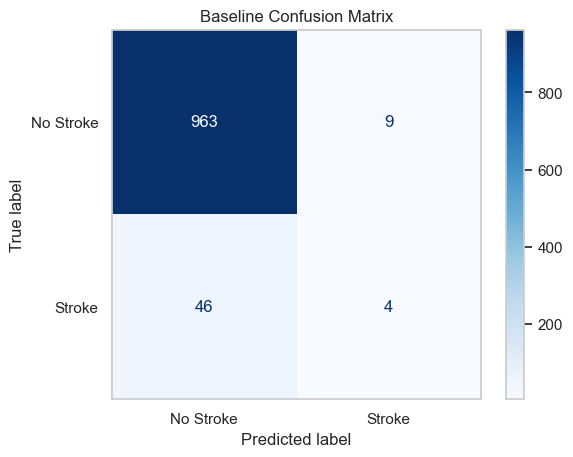

In [227]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
print("--Classification report--")
print(classification_report(y_test,y_pred))
# Generate the confusion matrix to see exactly where the model succeeded and failed
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues')
plt.title('Baseline Confusion Matrix')
plt.grid(False) # Turn off the seaborn grid lines for a cleaner matrix look
plt.show()

Randomforest Classifier Model 

In [228]:
# Train the pipeline using train dataset 
full_pipeline_RF.fit(x_train,y_train)
#test the pipeline using test dataset and see how the model performs on unseen data
y_pred_rf=full_pipeline_RF.predict(x_test)

--Classification report Random Forest Classifier--
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.92      1022



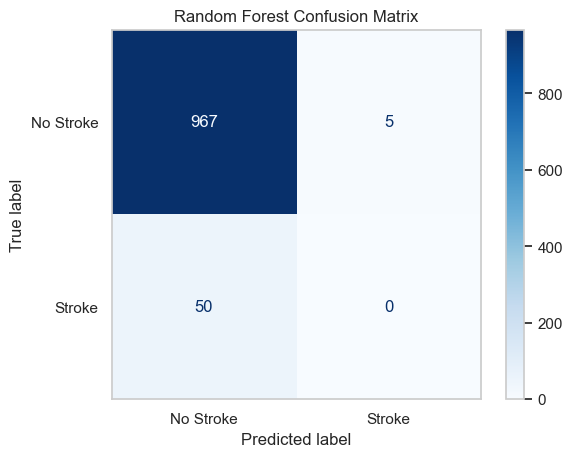

In [229]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
print("--Classification report Random Forest Classifier--")
print(classification_report(y_test,y_pred_rf))
# Generate the confusion matrix to see exactly where the model succeeded and failed
cm = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.grid(False) # Turn off the seaborn grid lines for a cleaner matrix look
plt.show()

# Handling Imbalance CLass 


In [230]:
#Calculate ratio of negative instances to positive instances 
balance_ratio=sum(y_train==0)/sum(y_train==1)
print(f"Calculated scale_pos_weight: {balance_ratio:.2f}")

Calculated scale_pos_weight: 19.54


In [231]:
#Re-initialize the pipeline 
tuned_pipeline=Pipeline([
    ('feature engineering',custom_fe),
    ('preprocessor',preprocessor),
    ("classifier",XGBClassifier(
        scale_pos_weight=balance_ratio,
        random_state=42,
        eval_metric='logloss',
        max_depth=3,
        learning_rate=0.01,
        n_estimator=100
    ))
])
# Train the model 
tuned_pipeline.fit(x_train,y_train)
#Test model on unseen data 
y_tuned_pred=tuned_pipeline.predict(x_test)


--Classification Report of Tuned Model--
              precision    recall  f1-score   support

           0       0.99      0.66      0.79       972
           1       0.11      0.84      0.20        50

    accuracy                           0.67      1022
   macro avg       0.55      0.75      0.50      1022
weighted avg       0.94      0.67      0.76      1022



Text(0.5, 1.0, 'Imbalance-Aware Confusion Matrix')

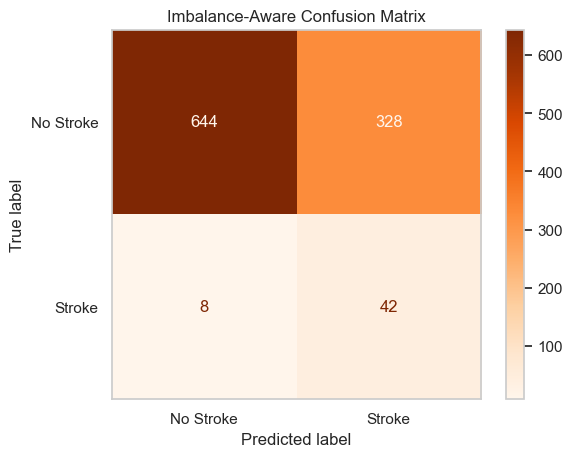

In [232]:
#We will evaluate the classification report and confusion metrix 
print("--Classification Report of Tuned Model--")
print(classification_report(y_test,y_tuned_pred))
cm_tuned=confusion_matrix(y_test,y_tuned_pred)
disp_tuned=ConfusionMatrixDisplay(confusion_matrix=cm_tuned,display_labels=['No Stroke','Stroke'])
disp_tuned.plot(cmap='Oranges')
plt.grid(False)
plt.title('Imbalance-Aware Confusion Matrix')

Tuned Random Forest Classifier 

In [233]:
#Re-initialize the pipeline 
tuned_pipeline_rf=Pipeline([
    ('feature engineering',custom_fe),
    ('preprocessor',preprocessor),
    ("classifier",RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        max_features="sqrt",
        max_depth=3,
        n_estimators=200,
        oob_score=True
    ))
])
# Train the model 
tuned_pipeline_rf.fit(x_train,y_train)
#Test model on unseen data 
y_tuned_pred_rf=tuned_pipeline_rf.predict(x_test)

--Classification Report of Tuned Model(Random Forest Classifier--
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



Text(0.5, 1.0, 'Imbalance-Aware Confusion Matrix')

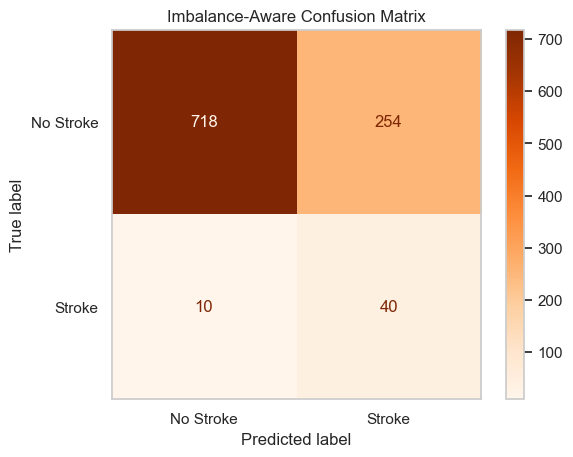

In [234]:
#We will evaluate the classification report and confusion metrix 
print("--Classification Report of Tuned Model(Random Forest Classifier--")
print(classification_report(y_test,y_tuned_pred_rf))
cm_tuned=confusion_matrix(y_test,y_tuned_pred_rf)
disp_tuned=ConfusionMatrixDisplay(confusion_matrix=cm_tuned,display_labels=['No Stroke','Stroke'])
disp_tuned.plot(cmap='Oranges')
plt.grid(False)
plt.title('Imbalance-Aware Confusion Matrix')

# Handling Imbalance class : SMOTE

--- SMOTE Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.80      0.88       972
           1       0.15      0.70      0.25        50

    accuracy                           0.79      1022
   macro avg       0.57      0.75      0.56      1022
weighted avg       0.94      0.79      0.85      1022



<function matplotlib.pyplot.show(close=None, block=None)>

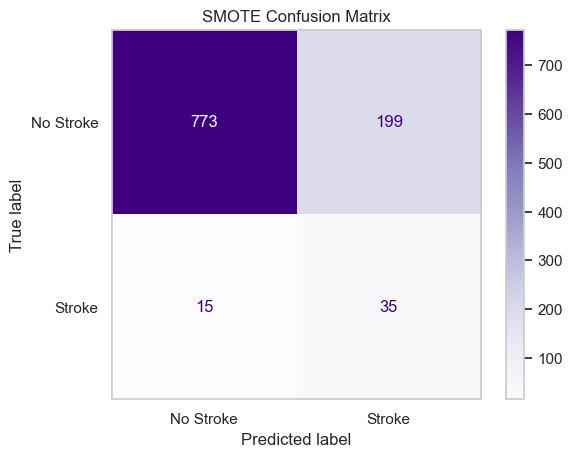

In [236]:
# Create new pipeline on SMOTE data 
# Imblearn has a special Pipeline for this!
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# smote_pipeline=ImbPipeline([  
#     ('feature engineering',custom_fe),
#     ('preprocessor',preprocessor),
#     ('smote',SMOTE(random_state=42)),
#     ("classifier",XGBClassifier(
#         random_state=42,
#         eval_metric='logloss',
#         max_depth=3,
#         learning_rate=0.01,
#         n_estimator=100
#     ))
    
# ])
smote_pipeline=ImbPipeline([  
    ('feature engineering',custom_fe),
    ('preprocessor',preprocessor),
    ('smote',SMOTE(random_state=42)),
    ("classifier",RandomForestClassifier(
        random_state=42,
        max_features="sqrt",
        max_depth=3,
        n_estimators=200,
        oob_score=True
    ))])
# Train the model
smote_pipeline.fit(x_train,y_train)
# Test model on unseen data 
y_smote_pred=smote_pipeline.predict(x_test)
print("--- SMOTE Classification Report ---")
print(classification_report(y_test, y_smote_pred))

# Plot SMOTE Confusion Matrix
cm_smote = confusion_matrix(y_test, y_smote_pred)
disp_smote = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=['No Stroke', 'Stroke'])
disp_smote.plot(cmap='Purples')
plt.title('SMOTE Confusion Matrix')
plt.grid(False)
plt.show

#  Hyperparameter Tuning & Threshold Tuning

In [238]:

from sklearn.model_selection import GridSearchCV

# 1. Define the "Grid" of settings we want to test FOR THE CLASSIFIER IN THE PIPELINE
param_grid = {
    'classifier__max_depth': [3, 5],                
    'classifier__n_estimators': [100,200] ,
    'classifier__max_features' :["sqrt","log2"]       
}

# 2. We use our previously defined weighted pipeline
base_weighted_pipeline = Pipeline([
    ('feature_engineering', custom_fe),
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight="balanced",oob_score=True, random_state=42))
])

# 3. Setup GridSearchCV 
# scoring='recall' tells it to explicitly hunt for the model that catches the MOST Strokes!
grid_search = GridSearchCV(
    estimator=base_weighted_pipeline, 
    param_grid=param_grid, 
    cv=3, 
    scoring='recall', 
    verbose=1
)

# 4. Run the Grid Search!
print("Starting Grid Search... this will train 24 completely separate models")
grid_search.fit(x_train, y_train)

print("\n🏆 Grid Search Completed!")
print(f"Best Hyperparameters Found: {grid_search.best_params_}")

Starting Grid Search... this will train 24 completely separate models
Fitting 3 folds for each of 8 candidates, totalling 24 fits

🏆 Grid Search Completed!
Best Hyperparameters Found: {'classifier__max_depth': 3, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}


--- Final Optimized (Weighted GridSearch) Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



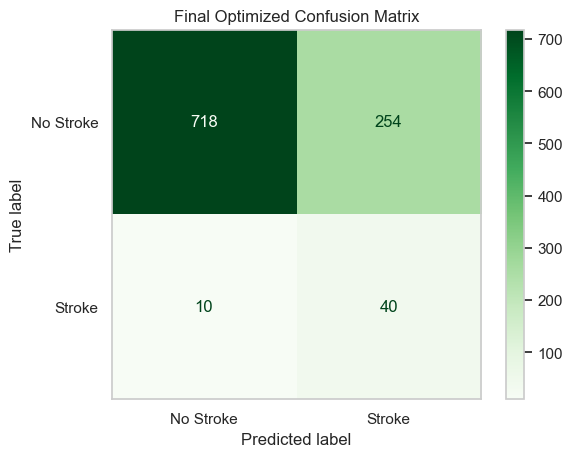

In [239]:
# 5. Extract the optimized pipeline and test it
best_pipeline = grid_search.best_estimator_

y_pred_best = best_pipeline.predict(x_test)

print("--- Final Optimized (Weighted GridSearch) Classification Report ---")
print(classification_report(y_test, y_pred_best))

# Final Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['No Stroke', 'Stroke'])
disp_best.plot(cmap='Greens')
plt.title('Final Optimized Confusion Matrix')
plt.grid(False)
plt.show()